=== 数据概览 ===
地块数据形状: (54, 4)
作物数据形状: (41, 5)
2023年种植情况形状: (87, 6)
2023年统计数据形状: (107, 8)

=== 地块类型分布 ===
地块类型
普通大棚     16
梯田       14
水浇地       8
平旱地       6
山坡地       6
智慧大棚      4
Name: count, dtype: int64

=== 作物类型分布 ===
作物类型
蔬菜        18
粮食        11
粮食（豆类）     5
食用菌        4
蔬菜（豆类）     3
Name: count, dtype: int64

=== 2023年种植季次分布 ===
种植季次
第二季    30
第一季    29
单季     28
Name: count, dtype: int64

=== 数据预处理完成 ===
清理后地块数据: (54, 4)
清理后作物数据: (41, 5)
清理后统计数据: (107, 9)


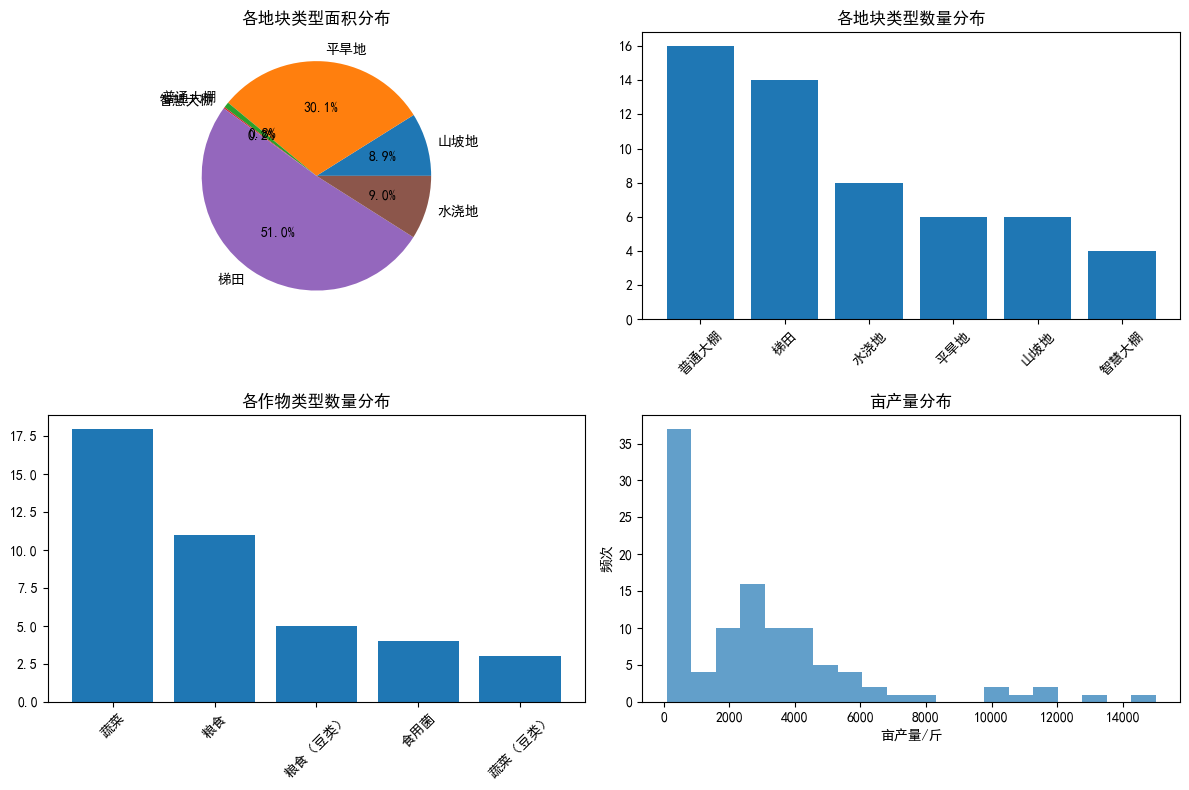


=== 关键统计信息 ===
总耕地面积: 1213.00 亩
露天耕地面积: 1201.00 亩
大棚数量: 20 个
大棚总面积: 12.00 亩

=== 作物基本信息 ===
粮食类作物数量: 16
蔬菜类作物数量: 21
食用菌类作物数量: 4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
land_data = pd.read_excel('D:\\pythonproject\\data_science\\excel_files\\附件1.xlsx', sheet_name='乡村的现有耕地')
crop_data = pd.read_excel('D:\\pythonproject\\data_science\\excel_files\\附件1.xlsx', sheet_name='乡村种植的农作物')
planting_2023 = pd.read_excel('D:\\pythonproject\\data_science\\excel_files\\附件2.xlsx', sheet_name='2023年的农作物种植情况')
stats_2023 = pd.read_excel('D:\\pythonproject\\data_science\\excel_files\\附件2.xlsx', sheet_name='2023年统计的相关数据')

print("=== 数据概览 ===")
print(f"地块数据形状: {land_data.shape}")
print(f"作物数据形状: {crop_data.shape}")
print(f"2023年种植情况形状: {planting_2023.shape}")
print(f"2023年统计数据形状: {stats_2023.shape}")

print("\n=== 地块类型分布 ===")
print(land_data['地块类型'].value_counts())

print("\n=== 作物类型分布 ===")
print(crop_data['作物类型'].value_counts())

print("\n=== 2023年种植季次分布 ===")
print(planting_2023['种植季次'].value_counts())

# 数据预处理
# 清理地块数据
land_data_clean = land_data.dropna(subset=['地块名称']).copy()
land_data_clean['地块类型'] = land_data_clean['地块类型'].str.strip()

# 清理作物数据
crop_data_clean = crop_data.dropna(subset=['作物编号']).copy()

# 清理2023年统计数据
stats_2023_clean = stats_2023.dropna(subset=['作物编号']).copy()

# 处理销售单价（取平均值）
def parse_price(price_str):
    if isinstance(price_str, str) and '-' in price_str:
        prices = price_str.split('-')
        return (float(prices[0]) + float(prices[1])) / 2
    elif isinstance(price_str, (int, float)):
        return float(price_str)
    else:
        return np.nan

stats_2023_clean['销售单价_平均'] = stats_2023_clean['销售单价/(元/斤)'].apply(parse_price)

print("\n=== 数据预处理完成 ===")
print(f"清理后地块数据: {land_data_clean.shape}")
print(f"清理后作物数据: {crop_data_clean.shape}")
print(f"清理后统计数据: {stats_2023_clean.shape}")

# 分析地块类型和面积分布
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
land_type_area = land_data_clean.groupby('地块类型')['地块面积/亩'].sum()
plt.pie(land_type_area.values, labels=land_type_area.index, autopct='%1.1f%%')
plt.title('各地块类型面积分布')

plt.subplot(2, 2, 2)
land_type_count = land_data_clean['地块类型'].value_counts()
plt.bar(land_type_count.index, land_type_count.values)
plt.title('各地块类型数量分布')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
crop_type_count = crop_data_clean['作物类型'].value_counts()
plt.bar(crop_type_count.index, crop_type_count.values)
plt.title('各作物类型数量分布')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
# 分析亩产量分布
plt.hist(stats_2023_clean['亩产量/斤'].dropna(), bins=20, alpha=0.7)
plt.title('亩产量分布')
plt.xlabel('亩产量/斤')
plt.ylabel('频次')

plt.tight_layout()
plt.savefig('step1_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 输出关键统计信息
print("\n=== 关键统计信息 ===")
print(f"总耕地面积: {land_data_clean['地块面积/亩'].sum():.2f} 亩")
print(f"露天耕地面积: {land_data_clean[land_data_clean['地块类型'].isin(['平旱地', '梯田', '山坡地', '水浇地'])]['地块面积/亩'].sum():.2f} 亩")
print(f"大棚数量: {land_data_clean[land_data_clean['地块类型'].str.contains('大棚')].shape[0]} 个")
print(f"大棚总面积: {land_data_clean[land_data_clean['地块类型'].str.contains('大棚')]['地块面积/亩'].sum():.2f} 亩")

print("\n=== 作物基本信息 ===")
print(f"粮食类作物数量: {crop_data_clean[crop_data_clean['作物类型'].str.contains('粮食')].shape[0]}")
print(f"蔬菜类作物数量: {crop_data_clean[crop_data_clean['作物类型'].str.contains('蔬菜')].shape[0]}")
print(f"食用菌类作物数量: {crop_data_clean[crop_data_clean['作物类型'].str.contains('食用菌')].shape[0]}")

# 保存预处理后的数据
land_data_clean.to_csv('land_data_clean.csv', index=False, encoding='utf-8-sig')
crop_data_clean.to_csv('crop_data_clean.csv', index=False, encoding='utf-8-sig')
stats_2023_clean.to_csv('stats_2023_clean.csv', index=False, encoding='utf-8-sig')
planting_2023.to_csv('planting_2023.csv', index=False, encoding='utf-8-sig')